# ARG-based analysis of European crows

In [1]:
import tskit
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# set up

get population of each sample (defined by Gwee et al)

In [2]:
poplabels = []
with open('data/poplabels.txt','r') as f:
    next(f)
    for line in f:
        poplabels.append(line.strip().split()[1])
pops, ixs = np.unique(poplabels,return_index=True)

aesthetics for plotting

In [3]:
poporder = ['cor1','cor3','cor2',
            'hyb1',
            'cnx5','cnx1','cnx3','cnx2','cnx4','cnx6',
            'hyb2',
            'ori1', 'ori2', 'ori3',
            'pec1']
colormap = {
    'cor1': plt.cm.tab10(3), 'cor2': plt.cm.tab10(3), 'cor3': plt.cm.tab10(3), 
    'hyb1': plt.cm.tab10(4),     
    'cnx1': plt.cm.tab10(0), 'cnx2': plt.cm.tab10(0), 'cnx3': plt.cm.tab10(0), 'cnx4': plt.cm.tab10(0), 'cnx5': plt.cm.tab10(0), 'cnx6': plt.cm.tab10(0),
    'hyb2': plt.cm.tab10(2),  
    'ori1': plt.cm.tab10(1), 'ori2': plt.cm.tab10(1), 'ori3': plt.cm.tab10(1), 
    'pec1': 'black'
}
markermap = {
    'cor1': '<', 'cor2': '>', 'cor3': 'o', 
    'hyb1': 'X',     
    'cnx1': 'o', 'cnx2': 's', 'cnx3': '^', 'cnx4': '>', 'cnx5': '<', 'cnx6': 'v',
    'hyb2': 'X',  
    'ori1': '<', 'ori2': '^', 'ori3': '>', 
    'pec1': 'o'
}
labelmap = {
    'cor1': 'corone-spain', 'cor2': 'corone-germany', 'cor3': 'corone-france', 
    'hyb1': 'corone-cornix hybrid',     
    'cnx1': 'cornix-italy', 'cnx2': 'cornix-bulgaria/levant', 'cnx3': 'cornix-poland/sweden', 'cnx4': 'cornix-russia', 'cnx5': 'cornix-corsica', 'cnx6': 'cornix-iraq',
    'hyb2': 'cornix-orientalis hybrid',  
    'ori1': 'orientalis-west', 'ori2': 'orientalis-north', 'ori3': 'orientalis-east', 
    'pec1': 'pectoralis'
}

chromosome names

In [4]:
chrmap =  {
           'chr1': 'NC_046332.1',
           'chr1A': 'NC_047057.1',
           'chr2': 'NC_046333.1',
           'chr3': 'NC_047056.1',
           'chr4': 'NC_046334.1',
           'chr4A': 'NC_047058.1',
           'chr5': 'NC_046335.1',
           'chr6': 'NC_046336.1',
           'chr7': 'NC_046337.1',
           'chr8': 'NC_046338.1',
           'chr9': 'NC_046339.1',
           'chr10': 'NC_046340.1',
           'chr11': 'NC_046341.1',
           'chr12': 'NC_046342.1',
           'chr13': 'NC_046343.1',
           'chr14': 'NC_046344.1',
           'chr15': 'NC_046345.1',
           'chr17': 'NC_046346.1',
           'chr18': 'NC_046347.1',
           'chr19': 'NC_046348.1',
           'chr20': 'NC_046349.1',
           'chr21': 'NC_046350.1',
           'chr22': 'NC_046351.1',
           'chr23': 'NC_046352.1',
           'chr24': 'NC_046353.1',
           'chr26': 'NC_046354.1',
           'chr27': 'NC_046355.1',
           'chr28': 'NC_046356.1',
           'scaffold1': 'NW_024108678.1', 
           'scaffold2': 'NW_024108687.1',
           'scaffold3': 'NW_024108688.1',
           'scaffold4': 'NW_024108689.1',
           'scaffold5': 'NW_024108690.1',
           'scaffold6': 'NW_024108691.1',
           'scaffold7': 'NW_024108692.1',
           'scaffold8': 'NW_024108693.1',
           'scaffold9': 'NW_024108694.1',
           'scaffold10': 'NW_024108679.1',
           'scaffold11': 'NW_024108680.1',
           'scaffold12': 'NW_024108681.1',
           'scaffold14': 'NW_024108682.1',
           'scaffold15': 'NW_024108683.1',
           'scaffold16': 'NW_024108684.1',
           'scaffold17': 'NW_024108685.1',
           'scaffold18': 'NW_024108686.1',
           'chrZ': 'NC_046357.1',
           'chrM': 'NC_062298.1',
}

sample locations

In [5]:
sample_locations = np.load('data/locations.npy').repeat(2,axis=0)

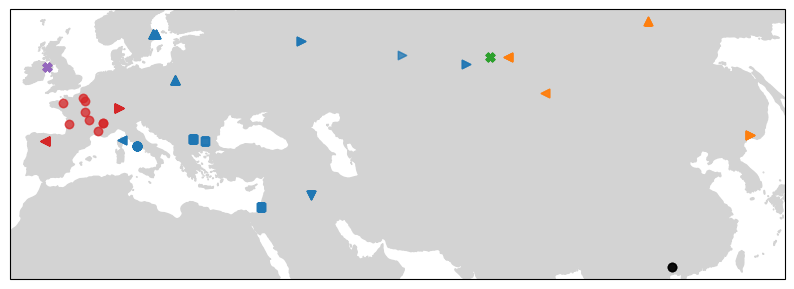

In [20]:
fig = plt.figure(figsize=(10,10))

projection = ccrs.Robinson()
data_crs = ccrs.PlateCarree() #data supplied in lat/long

ax = plt.axes(projection=projection)
ax.add_feature(cfeature.LAND, color='lightgray')

for pop in poporder:
    data = sample_locations[np.where(np.array(poplabels)==pop)]
    ax.scatter(data[:,0], data[:,1], color=colormap[pop], alpha=0.5, marker=markermap[pop], transform=data_crs)

plt.savefig('plots/sample_locations.png')
plt.show()

# results

## 1. pca for generic chromosome roughly matches geograhy (isolation by distance)

In [21]:
chrname = 'chr1'
# ts = tskit.load('data/trees/%s/134inds.trees' %chrmap[chrname])
# pca = ts.pca(2, random_seed=1) #run pca with 2 axes
# np.save('data/pca_%s.npy' %chrname, pca.factors)
pcafactors = np.load('data/pca_%s.npy' %chrname)

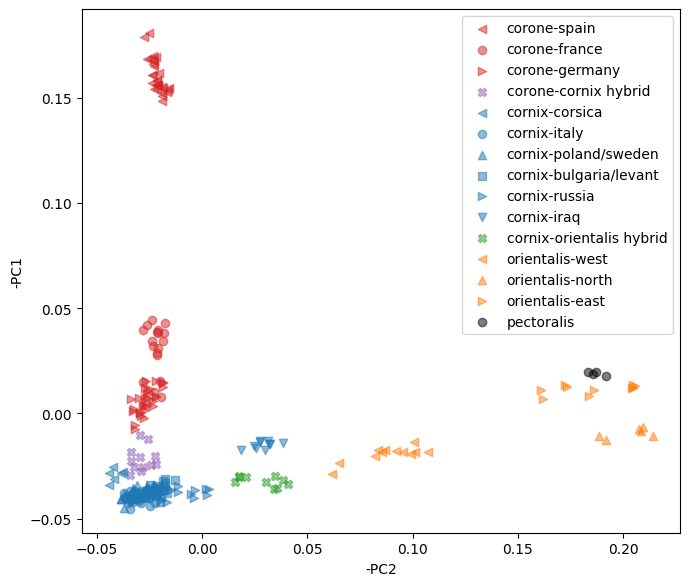

In [22]:
fig = plt.figure(figsize=(7,7))

ax = plt.subplot()

for pop in poporder:
    data = pcafactors[np.where(np.array(poplabels)==pop)]
    ax.scatter(-data[:,1], -data[:,0], color=colormap[pop], alpha=0.5, marker=markermap[pop], label=labelmap[pop])

ax.legend()

ax.set_xlabel('-PC2')
ax.set_ylabel('-PC1')
ax.set_aspect(1)

plt.tight_layout()
plt.savefig('plots/pca_%s.png' %chrname)
plt.show()

## 2. pca for chr18 is different: corone collapse, hybrids spread

In [9]:
# chrname = 'chr18'
# ts18 = tskit.load('data/trees/%s/134inds.trees' %chrmap[chrname])

In [10]:
# chrname = 'chr18'
# pca18 = ts18.pca(2, random_seed=1) #run pca with 2 axes

In [23]:
chrname = 'chr18'
# np.save('data/pca_%s.npy' %chrname, pca18.factors)
pcafactors18 = np.load('data/pca_%s.npy' %chrname)

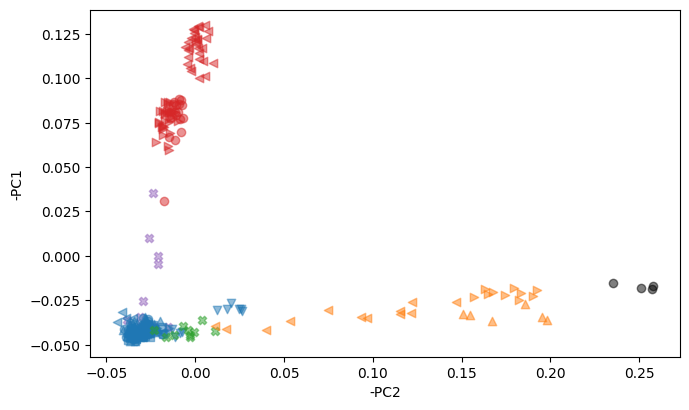

In [24]:
fig = plt.figure(figsize=(7,7))

ax = plt.subplot()

for pop in poporder:
    data = pcafactors18[np.where(np.array(poplabels)==pop)]
    ax.scatter(-data[:,1], -data[:,0], color=colormap[pop], alpha=0.5, marker=markermap[pop], label=labelmap[pop])

# ax.legend()

ax.set_xlabel('-PC2')
ax.set_ylabel('-PC1')
ax.set_aspect(1)

plt.tight_layout()
plt.savefig('plots/pca_%s.png' %chrname)
plt.show()

## 3. fst (corone-cornix) peak on chr18

In [25]:
fst = []
windows = []
fstchrs = []
for c in chrmap.keys():
    try:
        fst.append(np.load('data/fst_%s.npy' %chrmap[c]))
        windows.append(np.load('data/fst_windows_%s.npy' %chrmap[c]))
        fstchrs.append(c)
    except:
        print('missing' + c)

missingscaffold4
missingscaffold5
missingscaffold6
missingscaffold7
missingscaffold8
missingscaffold9
missingscaffold11
missingscaffold12
missingscaffold18
missingchrZ
missingchrM


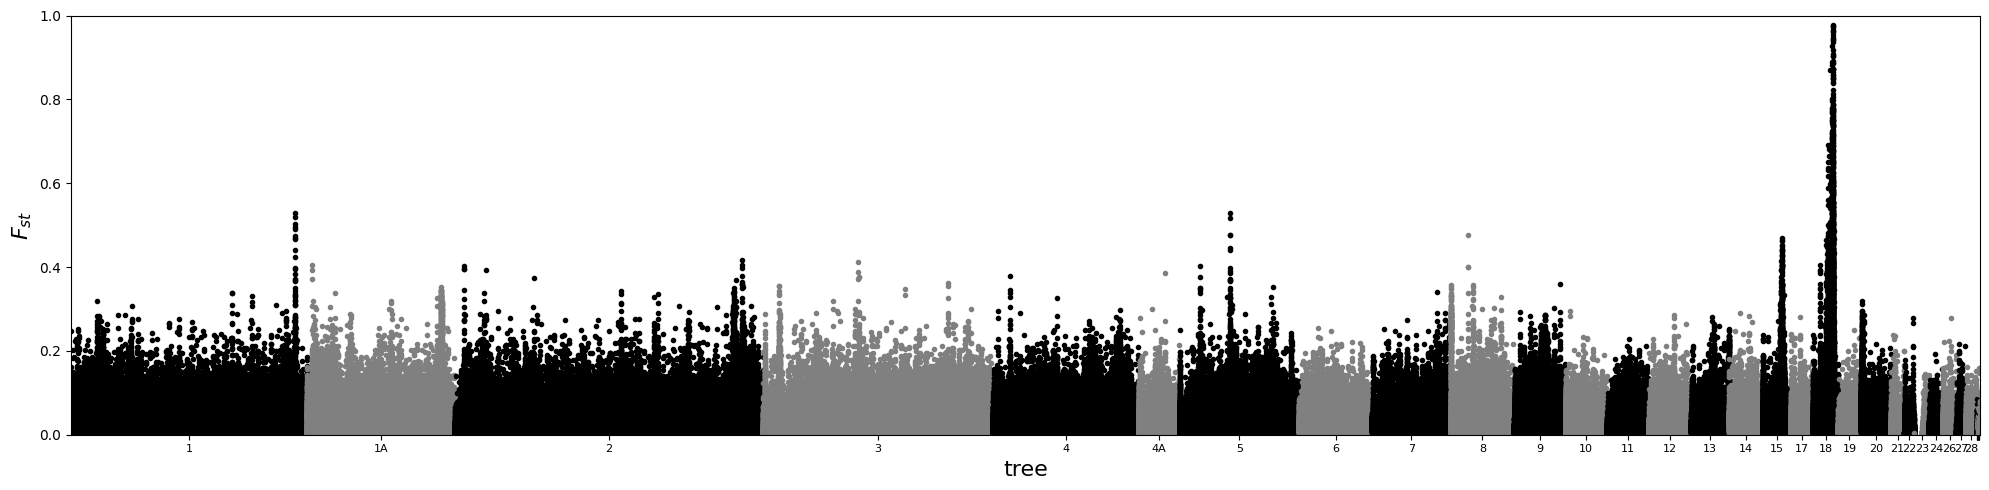

In [26]:
def colors(i):
    if i%2 == 0:
        return 'k'
    else:
        return 'gray'

fig = plt.figure(figsize=(20,5))
ax = plt.axes()

end = 0
xticks = []
for i,[b,f] in enumerate(zip(windows,fst)):
    ax.plot([end+i for i in b[:-1]],f,'.',color=colors(i))
    xticks.append(end + b[-1]/2)
    end += b[-1]
    
# plt.plot([0,end],[0.2,0.2],'--k')
ax.set_xlim(0,end)
ax.set_ylim(0,1)
ax.set_xticks(xticks,[c[3:] if c[:3]=='chr' else '' for c in fstchrs], fontsize=8)
ax.set_ylabel(r'$F_{st}$', fontsize=16)
ax.set_xlabel('tree', fontsize=16)

plt.tight_layout()
plt.savefig('plots/fst_corone-cornix.png')
plt.show()

## 4. fst peak on chr18 due to gene flow barrier, not sweeps

and we can dig into the cause of this fst peak a bit -- barrier locus vs species-specific sweeps (see wang & coop 2022)

In [27]:
chrname = 'chr18'
ts = tskit.load('data/trees/%s/134inds.trees' %chrmap[chrname])

In [28]:
# coroneix = [i for i,j in enumerate(poplabels) if j[2]=='r']
# cornixix = [i for i,j in enumerate(poplabels) if j[2]=='x']

In [9]:
# maxtmrcas = []
# mintmrcas = []
# for tree in ts.trees():
    # maxtmrca = [0,0]
    # for n,ixs in enumerate([coroneix,cornixix]):
    #     for i in ixs:
    #         for j in ixs[:i]:
    #             tmrca = tree.tmrca(i,j)
    #             if tmrca > maxtmrca[n]:
    #                 maxtmrca[n] = tmrca
    # maxtmrcas.append(maxtmrca)
    # mintmrca = tree.time(tree.root)
    # for i in coroneix:
    #     for j in cornixix:
    #         tmrca = tree.tmrca(i,j)
    #         if tmrca < mintmrca:
    #             mintmrca = tmrca
    # mintmrcas.append(mintmrca)
# np.save('data/maxtmrcas_chr18.npy', np.array(maxtmrcas))
# np.save('data/mintmrcas_chr18.npy', np.array(mintmrcas))

In [28]:
maxtmrcas = np.load('data/maxtmrcas_chr18.npy')
mintmrcas = np.load('data/mintmrcas_chr18.npy')

In [29]:
window = list(ts.breakpoints())
windows = [(i+j)/2 for i,j in zip(window[1:],window[:-1])]

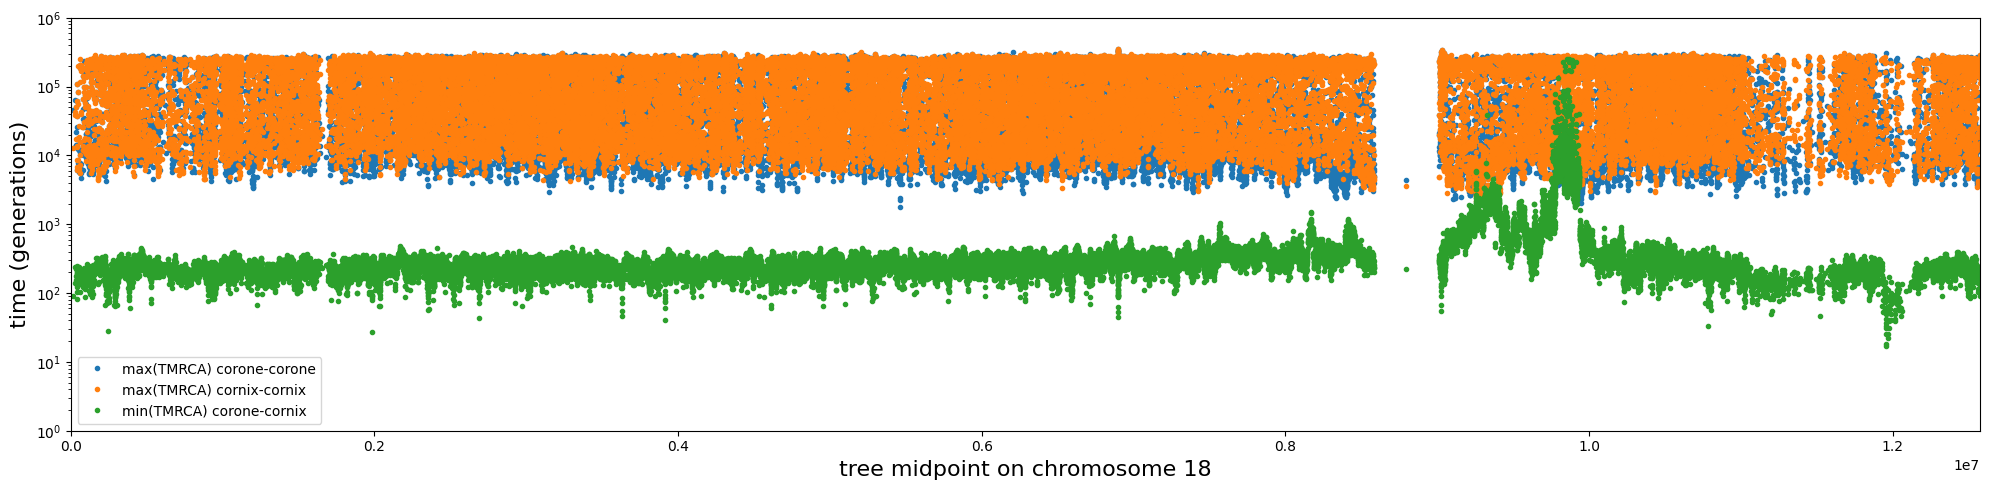

In [30]:
fig = plt.figure(figsize=(20,5))
ax = plt.axes() 


ax.plot(windows, maxtmrcas[:,0], '.', label='max(TMRCA) corone-corone')
ax.plot(windows, maxtmrcas[:,1], '.', label='max(TMRCA) cornix-cornix')

ax.plot(windows, mintmrcas, '.', label='min(TMRCA) corone-cornix')

ax.set_xlim(0,windows[-1])
ax.set_yscale('log')
ax.set_ylim(1,1e6)
ax.set_xlabel('tree midpoint on chromosome 18', fontsize=16)
ax.set_ylabel('time (generations)', fontsize=16)
plt.legend()
plt.tight_layout()

plt.savefig('plots/tmrcas_chr18.png')
plt.show()

## 5. Directly visualizing the high fst tree

In [31]:
c = 'chr18'
fst = np.load('data/fst_%s.npy' %chrmap[c])
ts = tskit.load('data/trees/%s/134inds.trees' %chrmap[c])

In [32]:
coroneix = [i for i,j in enumerate(poplabels) if j[2]=='r']
cornixix = [i for i,j in enumerate(poplabels) if j[2]=='x']
styles = []
for i in ts.samples():
    if i in coroneix:
        color = 'red'
    elif i in cornixix:
        color = 'blue'
    else:
        color = 'gray'
    s = f".n{i} .sym " + "{" + f"fill: {color}" + "}"    
    styles.append(s)
css_string = " ".join(styles)

In [33]:
peak = np.nanargmax(fst)
tree = ts.at_index(peak)

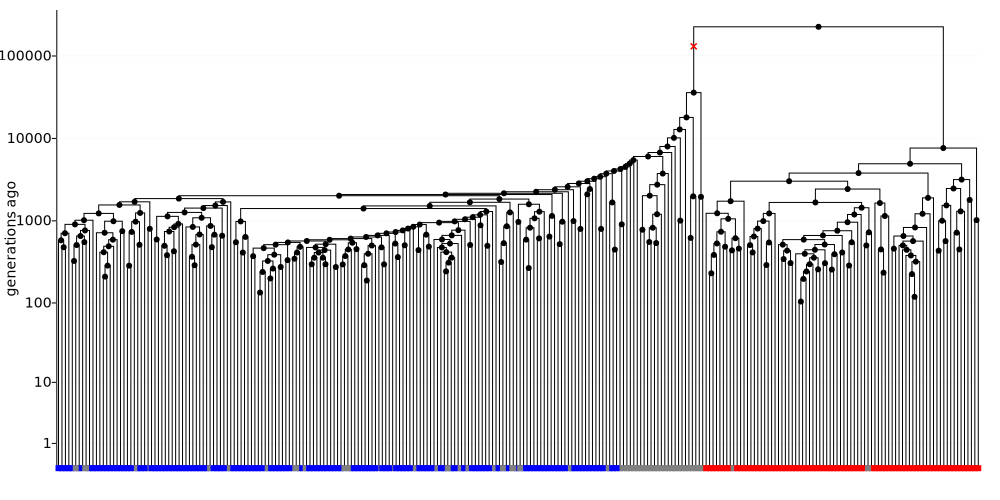

In [35]:
tree.draw_svg(
    size=(1000,500),
    node_labels={}, mutation_labels={}, style=css_string,
    time_scale="log_time",  y_axis=True, y_gridlines=True, y_ticks=[1, 10, 100, 1000, 10000,100000], y_label="generations ago",
    path='plots/fst_tree.png'
)

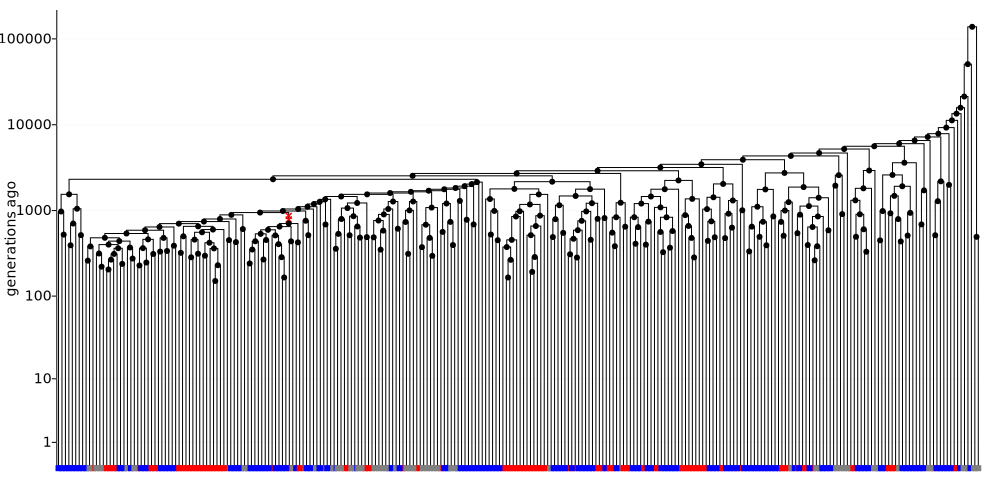

In [36]:
# i = np.random.choice(ts.num_trees)
i = 2453
tree = ts.at_index(i)
tree.draw_svg(
    size=(1000,500),
    node_labels={}, mutation_labels={}, style=css_string,
    time_scale="log_time",  y_axis=True, y_gridlines=True, y_ticks=[1, 10, 100, 1000, 10000,100000], y_label="generations ago",
    path='plots/random_tree.png'
)